# L5 · Gradient descent on a quadratic & the learning rate

**One idea:** on $L(\theta)=(\theta-3)^2$, the update is
$\theta_{t+1}=\theta_t-2\eta(\theta_t-3)$. The learning rate decides whether we
crawl, converge fast, oscillate, or diverge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

def gd(lr, steps=40, theta0=0.0):
    theta = theta0
    traj = [theta]
    for _ in range(steps):
        grad = 2*(theta - 3)         # dL/dtheta
        theta = theta - lr*grad
        traj.append(theta)
    return np.array(traj)

## 1. Reproduce the lecture trace ($\eta=0.1$, $\theta_0=0$)
Expected $\theta_1=0.6,\ \theta_2=1.08,\ \theta_3=1.464$.

In [2]:
traj = gd(lr=0.1)
print("theta_1, theta_2, theta_3 =", np.round(traj[1:4], 4))

theta_1, theta_2, theta_3 = [0.6   1.08  1.464]


## 2. Four learning-rate regimes

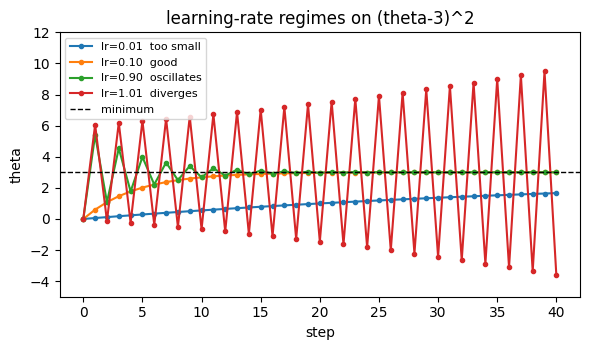

In [3]:
plt.figure(figsize=(6, 3.6))
for lr, label in [(0.01, "0.01  too small"),
                  (0.10, "0.10  good"),
                  (0.90, "0.90  oscillates"),
                  (1.01, "1.01  diverges")]:
    t = gd(lr)
    plt.plot(t, marker=".", label=f"lr={label}")
plt.axhline(3, color="k", ls="--", lw=1, label="minimum")
plt.ylim(-5, 12); plt.xlabel("step"); plt.ylabel("theta")
plt.title("learning-rate regimes on (theta-3)^2"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Takeaway
- The gradient sets the **direction**; the learning rate sets the **step size**.
- Too small → slow; well-chosen → fast; too large → oscillate; beyond a stability
  threshold → **diverge**. Choosing $\eta$ is the first job of an optimizer.